In [2]:
import os
import cv2
import json
import torch
import csv
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
import pdb
import time
from PIL import Image
import glob
import sys 
import scipy.io.wavfile as wav
from scipy import signal
import random
import soundfile as sf

In [3]:
# class GetAudioVideoDataset(Dataset):

#     def __init__(self, args, mode='train', transforms=None):
 
#         data = []
#         if args.testset == 'flickr':
#             testcsv = 'metadata/flickr_test.csv'
#         elif args.testset == 'vggss':
#             testcsv = 'metadata/vggss_test.csv'

#         with open(testcsv) as f:
#             csv_reader = csv.reader(f)
#             for item in csv_reader:
#                 data.append(item[0] + '.mp4')
#         self.audio_path = args.data_path + 'audio/'
#         self.video_path = args.data_path + 'frames/'

#         self.imgSize = args.image_size 

#         self.mode = mode
#         self.transforms = transforms
#         # initialize video transform
#         self._init_atransform()  # audio spectrogram의 텐서화 및 정규화를 수행
#         self._init_transform() # image 변환 작업을 수행
#         #  Retrieve list of audio and video files
#         self.video_files = []
   
#         for item in data[:]:
#             self.video_files.append(item )
#         print(len(self.video_files)) # video_files의 길이를 반환하여 데이터의 개수를 알려줌
#         self.count = 0

#     def _init_transform(self):
#         mean = [0.485, 0.456, 0.406]
#         std = [0.229, 0.224, 0.225]
#         if self.mode == 'train': # 훈련 모드
#             self.img_transform = transforms.Compose([
#                 transforms.Resize(int(self.imgSize * 1.1), Image.BICUBIC), # image를 self.imgSize의 1.1배 크기로 확대
#                 transforms.RandomCrop(self.imgSize), # random crop을 통해 image의 일부분을 임의로 자름
#                 transforms.RandomHorizontalFlip(), # 50% 확률로 image를 좌우로 뒤집어 데이터 다양성을 더함.
#                 transforms.CenterCrop(self.imgSize), # 중앙 부분을 잘라냄
#                 transforms.ToTensor(),
#                 transforms.Normalize(mean, std)]) # 텐서로 변환 후 정규화
#         else: # test 모드
#             self.img_transform = transforms.Compose([
#                 transforms.Resize(self.imgSize, Image.BICUBIC),
#                 transforms.CenterCrop(self.imgSize),
#                 transforms.ToTensor(),
#                 transforms.Normalize(mean, std)]) # 텐서로 변환 후 정규화           

#     def _init_atransform(self):
#         self.aid_transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize(mean=[0.0], std=[12.0])])
#         # audio spectrogram data를 tensor 형식으로 변환. -> 표준 편차를 12.0으로 설정하여 정규화
# #  

#     def _load_frame(self, path):
#         img = Image.open(path).convert('RGB') # 주어진 경로에서 image를 읽고 RGB로 변환하여 반환
#         return img

#     def __len__(self):
#         # Consider all positive and negative examples
#         return len(self.video_files)  # self.length

#     def __getitem__(self, idx):
#         file = self.video_files[idx] # 주어진 인덱스 'idx'에 해당하는 img와 audio data를 가져와서 전처리 후 반환

#         # Image
#         frame = self.img_transform(self._load_frame(self.video_path + file[:-3] + 'jpg'))
#         frame_ori = np.array(self._load_frame(self.video_path  + file[:-3] + 'jpg'))
#         # Audio
#         samples, samplerate = sf.read(self.audio_path + file[:-3]+'wav')

#         # repeat if audio is too short -> audio 길이가 10초에 미치지 못하면, 필요한 길이만큼 반복하여 samples를 확장
#         if samples.shape[0] < samplerate * 10:
#             n = int(samplerate * 10 / samples.shape[0]) + 1
#             samples = np.tile(samples, n)
#         resamples = samples[:samplerate*10] # samples에서 정확히 10초를 잘라내어 resamples에 저장

#         resamples[resamples > 1.] = 1.
#         resamples[resamples < -1.] = -1.
#         frequencies, times, spectrogram = signal.spectrogram(resamples,samplerate, nperseg=512,noverlap=274) # audio spectrogram을 생성
#         spectrogram = np.log(spectrogram+ 1e-7) # spectrogram의 값을 log scale로 변환 -> spectrogram에 저장
#         spectrogram = self.aid_transform(spectrogram) # spectrogram data를 tensor로 변환하고 정규화
 

#         return frame,spectrogram,resamples,file,torch.tensor(frame_ori)

In [4]:
class GetAudioVideoDataset(Dataset):

    def __init__(self, args, mode='train', transforms=None):

        with open(args.json_file, 'r') as f:
            self.data = json.load(f)['data']
        
        self.imgSize = args.image_size 
        self.mode = mode
        self.transforms = transforms

        # initialize video transform
        self._init_atransform()  # audio spectrogram의 텐서화 및 정규화를 수행
        self._init_transform() # image 변환 작업을 수행
        #  Retrieve list of audio and video files

    def _init_transform(self):
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]

        if self.mode == 'train': # 훈련 모드
            self.img_transform = transforms.Compose([
                transforms.Resize(int(self.imgSize * 1.1), Image.BICUBIC), # image를 self.imgSize의 1.1배 크기로 확대
                transforms.RandomCrop(self.imgSize), # random crop을 통해 image의 일부분을 임의로 자름
                transforms.RandomHorizontalFlip(), # 50% 확률로 image를 좌우로 뒤집어 데이터 다양성을 더함.
                transforms.CenterCrop(self.imgSize), # 중앙 부분을 잘라냄
                transforms.ToTensor(),
                transforms.Normalize(mean, std)]) # 텐서로 변환 후 정규화
        else: # test 모드
            self.img_transform = transforms.Compose([
                transforms.Resize(self.imgSize, Image.BICUBIC),
                transforms.CenterCrop(self.imgSize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)]) # 텐서로 변환 후 정규화           

    def _init_atransform(self):
        self.aid_transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize(mean=[0.0], std=[12.0])])
        # audio spectrogram data를 tensor 형식으로 변환. -> 표준 편차를 12.0으로 설정하여 정규화
#  

    def _load_frame(self, path):
        img = Image.open(path).convert('RGB') # 주어진 경로에서 image를 읽고 RGB로 변환하여 반환
        return img

    def __len__(self):
        # Consider all positive and negative examples
        return len(self.data)  # self.length

    def __getitem__(self, idx):
        # json file에서 audio & video path 가져오기
        item = self.data[idx]
        video_id = item['video_id']
        audio_path = f"/mnt/scratch/users/sally/VGGsound_individual/train_practice/sample_audio/{video_id}.wav"
        video_path = f"/mnt/scratch/users/sally/VGGsound_individual/train_practice/sample_frames/frame_4/{video_id}.jpg"

        # image load 및 전처리
        frame = self.img_transform(self._load_frame(video_path))
        frame_ori = np.array(self._load_frame(video_path))
        
        # 오디오 로드 및 전처리
        samples, samplerate = sf.read(audio_path)


        # repeat if audio is too short -> audio 길이가 10초에 미치지 못하면, 필요한 길이만큼 반복하여 samples를 확장
        if samples.shape[0] < samplerate * 10:
            n = int(samplerate * 10 / samples.shape[0]) + 1
            samples = np.tile(samples, n)
        resamples = samples[:samplerate*10] # samples에서 정확히 10초를 잘라내어 resamples에 저장

        resamples[resamples > 1.] = 1.
        resamples[resamples < -1.] = -1.
        frequencies, times, spectrogram = signal.spectrogram(resamples,samplerate, nperseg=512,noverlap=274) # audio spectrogram을 생성
        spectrogram = np.log(spectrogram+ 1e-7) # spectrogram의 값을 log scale로 변환 -> spectrogram에 저장
        spectrogram = self.aid_transform(spectrogram) # spectrogram data를 tensor로 변환하고 정규화
 

        return frame,spectrogram,resamples,video_id,torch.tensor(frame_ori)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Checking first few samples from the dataset...
Sample 1


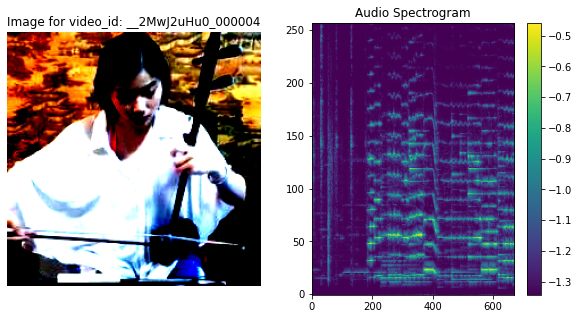

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Sample 2


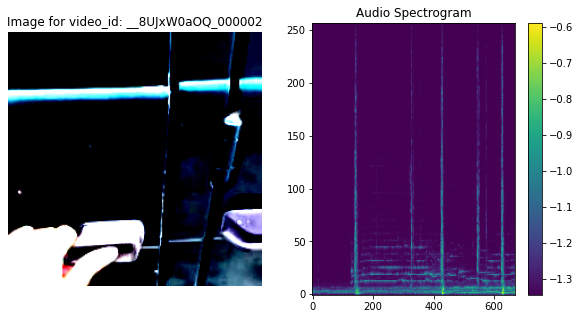

In [5]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from types import SimpleNamespace  # Namespace와 유사한 효과를 주기 위해 사용
# 필요한 경우, GetAudioVideoDataset 클래스를 선언한 모듈을 불러옵니다.
# from dataloader import GetAudioVideoDataset

# 데이터 확인 함수
def visualize_sample(data):
    frame, spectrogram, resamples, video_id, frame_ori = data

    # 배치 차원 제거
    frame = frame.squeeze(0)  # 배치 차원을 제거하여 3차원 텐서로 만듦
    spectrogram = spectrogram.squeeze(0)

    # 이미지 확인
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(frame.permute(1, 2, 0).numpy())  # frame 텐서를 이미지로 변환
    plt.title(f'Image for video_id: {video_id[0]}')  # video_id가 리스트 형태일 수 있으므로 첫 번째 항목 선택
    plt.axis('off')

    # 스펙트로그램 확인
    plt.subplot(1, 2, 2)
    plt.imshow(spectrogram[0].numpy(), aspect='auto', origin='lower')  # 스펙트로그램의 첫 채널 확인
    plt.title('Audio Spectrogram')
    plt.colorbar()
    plt.show()

def main():
    # JSON 파일 경로와 이미지 크기를 설정합니다.
    args = SimpleNamespace(
        json_file="/mnt/scratch/users/sally/VGGsound_individual/metadata/train_practice.json",  # 실제 JSON 파일 경로로 변경
        image_size=224
    )

    # 데이터셋 및 DataLoader 생성
    dataset = GetAudioVideoDataset(args, mode='test')
    dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

    # 샘플 데이터 확인
    print("Checking first few samples from the dataset...")
    for i, data in enumerate(dataloader):
        print(f"Sample {i+1}")
        visualize_sample(data)
        if i == 2:  # 3개의 샘플 확인 후 종료
            break

# main() 함수 실행
main()


In [ ]:
from DatasetLoader import GetAudioVideoDataset
args = SimpleNamespace(
    json_file="/mnt/scratch/users/individuals/VGGsound_individual/metadata/test.json",  # 실제 JSON 파일 경로로 변경
    image_size=224
)

testdataset = GetAudioVideoDataset(args, mode = 'test')
#dataloader = DataLoader(testdataset, batch_size=1, shuffle=True)
test_loader = torch.utils.data.DataLoader(testdataset, batch_size=10, shuffle=False,num_workers = 16)

from tqdm import tqdm
for step, (image, spec, _, name, _) in tqdm(enumerate(test_loader)):
    pass
# # 샘플 데이터 확인
# print("Checking first few samples from the dataset...")
# for i, data in enumerate(dataloader):
#     print(f"Sample {i+1}")
#     visualize_sample(data)
#     if i == 2:  # 3개의 샘플 확인 후 종료
#         break

1it [00:00, 11.41it/s]
